In [2]:
"""
2026-07-02 MY

Data: LINEQ (2026) national mean farm size recorded for WCA 1930...2020
Modified to match years 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020
Spatial method: nearest region, country
Temporal method: nearest WCA year (1990, 2000, 2010, 2020)

Note! All regions included and filled. It is expected that agricultural land mask 
is used later to mask out regions were no agricultural land exist (e.g. northern Canada).



"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.patches as mpatches

import seaborn as sns

import geopandas as gpd
import pandas as pd

#from scipy.spatial import cKDTree

from pathlib import Path

import pyreadr

<Axes: >

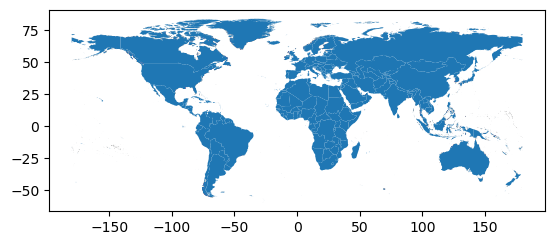

In [14]:
worldPolygons = '/Users/myliheik/Documents/projektit/2025-Water-Food-Futures/Piipponen/article_griddedprot/Data/Input/Polygons/gadm_410-levels.gpkg'
world = gpd.read_file(worldPolygons, layer='ADM_0')
world = world[~(world['COUNTRY'] == 'Antarctica')]
world.plot()

In [5]:
fp = '/Users/myliheik/Downloads/LINEQ_V1_FINAL.rds'

result = pyreadr.read_r(fp)
df = next(iter(result.values()))
print('FAO WCA rounds:')
df['wca_round'].min(), df['wca_round'].max()

FAO WCA rounds:


(1930.0, 2020.0)

In [8]:
df[df['country_area'] == 'Finland']

,iso03,m49,source_year,wca_round,country_area,region_name,sub_region_name,intermediate_region_name,lo_nhold_all,lo_land_all,...,lo_mean_g06,lo_mean_g07,lo_mean_g08,lo_mean_g09,lo_mean_g10,lo_mean_g11,census_years,url,source,unit_uid
95,FIN,246.0,1950.0,1950.0,Finland,Europe,Northern Europe,NaN,465655.0,8.199597e+06,...,28.453054,56.374516,140.809808,312.285582,757.645351,56606.539157,NaN,https://www.fao.org/statistics/resources/en?in...,Modeled estimates based on data tables publish...,FIN195001
96,FIN,246.0,1970.0,1970.0,Finland,Europe,Northern Europe,NaN,297257.0,2.669057e+06,...,27.717042,64.452469,157.729452,NaN,NaN,NaN,NaN,https://www.fao.org/statistics/resources/en?in...,Modeled estimates based on data tables publish...,FIN197001
97,FIN,246.0,1980.0,1980.0,Finland,Europe,Northern Europe,NaN,224721.0,2.462745e+06,...,28.311888,63.979735,143.914729,NaN,NaN,NaN,NaN,https://www.fao.org/statistics/resources/en?in...,Modeled estimates based on data tables publish...,FIN198001
98,FIN,246.0,1990.0,1990.0,Finland,Europe,Northern Europe,NaN,199385.0,1.236452e+07,...,29.570285,55.526092,142.029465,338.202231,719.553751,58849.829081,NaN,https://www.fao.org/world-census-agriculture/w...,Modeled estimates based on data tables publish...,FIN199001
428,FIN,246.0,2000.0,2000.0,Finland,Europe,Northern Europe,NaN,81200.0,5.881545e+06,...,31.023315,58.142155,142.280062,315.260848,701.657641,12802.592324,1999-2000,https://openknowledge.fao.org/handle/20.500.14...,Modeled estimates based on FAO WCA Main Result...,FIN200001
429,FIN,246.0,2010.0,2010.0,Finland,Europe,Northern Europe,NaN,63480.0,2.289981e+06,...,32.618374,68.838734,132.823401,250.904054,538.255252,NaN,2010,https://www.fao.org/3/ca6956en/CA6956EN-FI-dat...,Modeled estimates based on FAO WCA Main Result...,FIN201001
430,FIN,246.0,2020.0,2020.0,Finland,Europe,Northern Europe,NaN,45390.0,2.277075e+06,...,24.963395,57.029631,136.171792,289.546711,671.842364,1734.049578,2020,https://openknowledge.fao.org/handle/20.500.14...,Modeled estimates based on FAO WCA Main Result...,FIN202001


In [26]:
dfLatest = df[df['wca_round'] >= 1990]
dfLatest2 = world.merge(dfLatest, how = "right", left_on = 'GID_0', right_on = 'iso03')

In [27]:
len(world), len(dfLatest), len(dfLatest2)

(262, 357, 357)

In [28]:
dfLatest2.columns

Index(['GID_0', 'COUNTRY', 'geometry', 'iso03', 'm49', 'source_year',
       'wca_round', 'country_area', 'region_name', 'sub_region_name',
       'intermediate_region_name', 'lo_nhold_all', 'lo_land_all',
       'lo_mean_all', 'lo_median_all', 'lo_gini_all', 'lo_decile1_all',
       'lo_decile2_all', 'lo_decile3_all', 'lo_decile4_all', 'lo_decile5_all',
       'lo_decile6_all', 'lo_decile7_all', 'lo_decile8_all', 'lo_decile9_all',
       'lo_decile10_all', 'lo_nhold_g01', 'lo_nhold_g02', 'lo_nhold_g03',
       'lo_nhold_g04', 'lo_nhold_g05', 'lo_nhold_g06', 'lo_nhold_g07',
       'lo_nhold_g08', 'lo_nhold_g09', 'lo_nhold_g10', 'lo_nhold_g11',
       'lo_land_g01', 'lo_land_g02', 'lo_land_g03', 'lo_land_g04',
       'lo_land_g05', 'lo_land_g06', 'lo_land_g07', 'lo_land_g08',
       'lo_land_g09', 'lo_land_g10', 'lo_land_g11', 'lo_share_g01',
       'lo_share_g02', 'lo_share_g03', 'lo_share_g04', 'lo_share_g05',
       'lo_share_g06', 'lo_share_g07', 'lo_share_g08', 'lo_share_g09',
    

In [45]:
dfLatest3

,GID_0,COUNTRY,geometry,iso03,m49,source_year,wca_round,country_area,region_name,sub_region_name,intermediate_region_name,lo_mean_all,farm_size,FARMSIZE_CAT
0,ALB,Albania,"MULTIPOLYGON (((20.05408 39.69171, 20.03888 39...",ALB,8.0,1998.0,2000.0,Albania,Europe,Southern Europe,NaN,4.062274661,4.062275,2-5 ha
1,ARG,Argentina,"MULTIPOLYGON (((-68.61305 -52.65108, -68.61341...",ARG,32.0,1988.0,1990.0,Argentina,Americas,Latin America and the Caribbean,South America,468.9681914,468.968191,100-1000 ha
2,ASM,American Samoa,"MULTIPOLYGON (((-170.68064 -14.28248, -170.676...",ASM,16.0,1990.0,1990.0,American Samoa,Oceania,Polynesia,NaN,6.1171875,6.117188,5-20 ha
3,AUT,Austria,"MULTIPOLYGON (((14.28321 46.44377, 14.28309 46...",AUT,40.0,1990.0,1990.0,Austria,Europe,Western Europe,NaN,26.4174005,26.417400,20-50 ha
4,BEL,Belgium,"MULTIPOLYGON (((5.46629 49.49893, 5.4645 49.50...",BEL,56.0,1990.0,1990.0,Belgium,Europe,Western Europe,NaN,16.0629043358568,16.062904,5-20 ha
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,VNM,Vietnam,"MULTIPOLYGON (((106.00443 9.30487, 106.00031 9...",VNM,704.0,2011.0,2010.0,Viet Nam,Asia,South-eastern Asia,NaN,0.749943769,0.749944,0-2 ha
353,VNM,Vietnam,"MULTIPOLYGON (((106.00443 9.30487, 106.00031 9...",VNM,704.0,2016.0,2020.0,Viet Nam,Asia,South-eastern Asia,NaN,1.02650759297698,1.026508,0-2 ha
354,YEM,Yemen,"MULTIPOLYGON (((44.12514 12.63236, 44.12542 12...",YEM,887.0,2002.0,2000.0,Yemen,Asia,Western Asia,NaN,1.363849827,1.363850,0-2 ha
355,ZAF,South Africa,"MULTIPOLYGON (((19.66291 -34.78653, 19.66327 -...",ZAF,710.0,2017.0,2020.0,South Africa,Africa,Sub-Saharan Africa,Southern Africa,1232.3578899862,1232.357890,1000+ ha


In [41]:
dfLatest3['lo_mean_all'].astype('float')

0         4.062275
1       468.968191
2         6.117188
3        26.417400
4        16.062904
          ...     
352       0.749944
353       1.026508
354       1.363850
355    1232.357890
356       1.670405
Name: lo_mean_all, Length: 357, dtype: float64

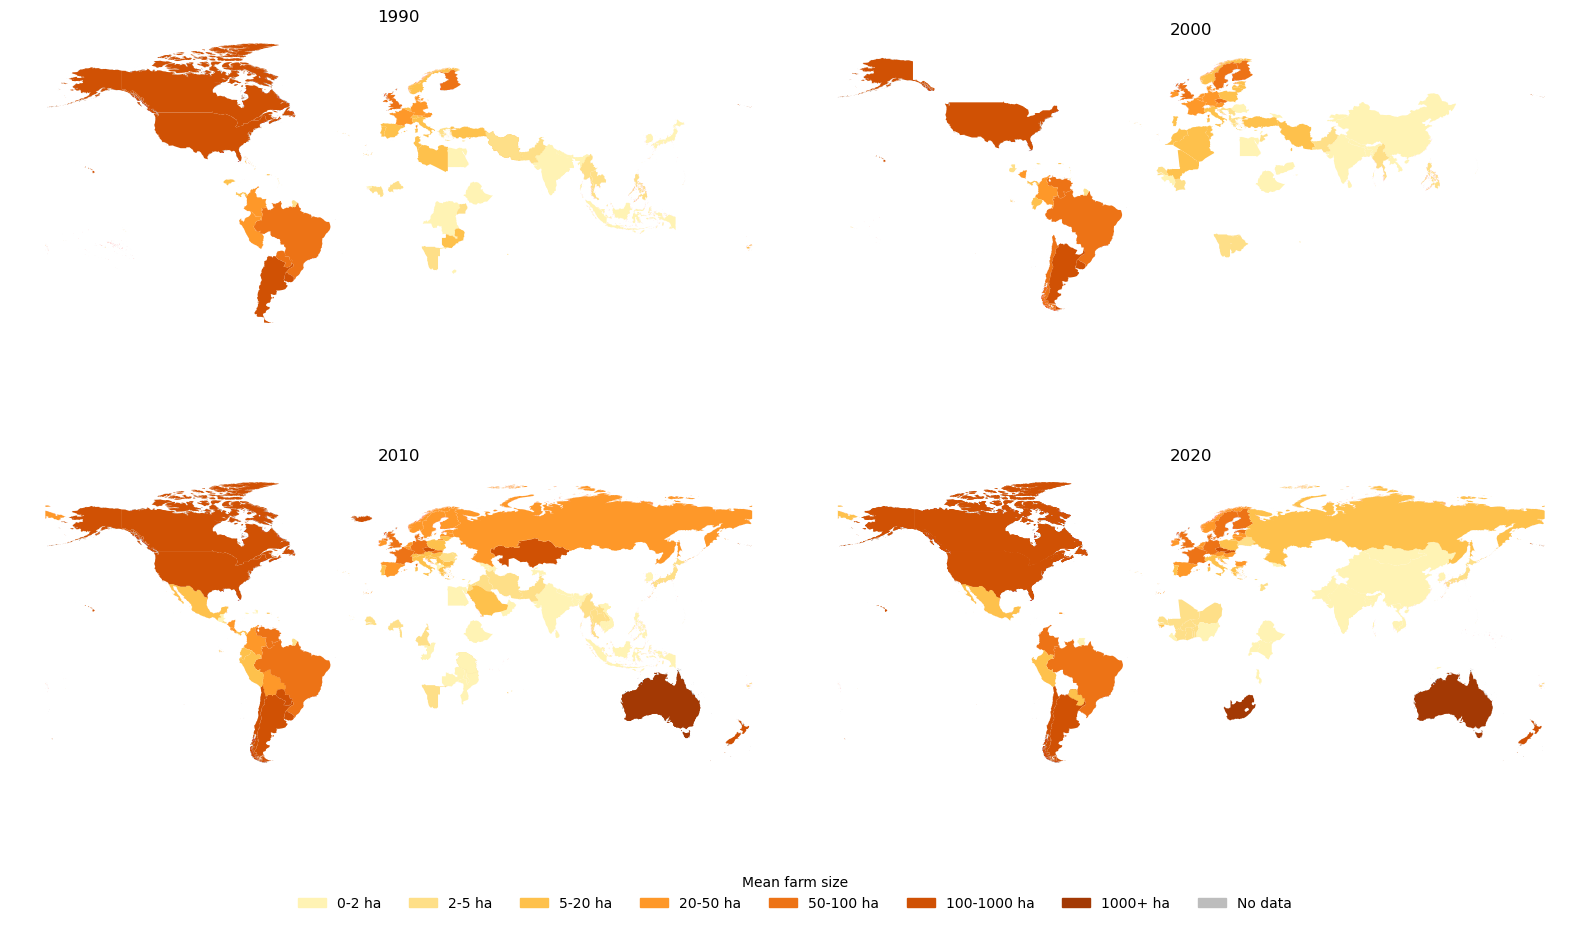

In [44]:
dfLatest3.assign(farm_size = dfLatest3['lo_mean_all'].astype('float'))

# bins, labels and colors
bins = [0, 2, 5, 20, 50, 100, 1000, np.inf]
labels = ['0-2 ha', '2-5 ha', '5-20 ha', '20-50 ha', '50-100 ha', '100-1000 ha', '1000+ ha']

# choose a 7-col sequential palette and convert to hex
#cmap = mpl.cm.get_cmap('YlOrBr')
cmap = mpl.colormaps.get_cmap('YlOrBr')   # or: cmap = mpl.colormaps['YlOrBr']

colors = [mpl.colors.to_hex(cmap(x)) for x in np.linspace(0.15, 0.85, len(labels))]
color_map = dict(zip(labels, colors))
nodata_color = '#bdbdbd'  # grey for no data

# make categorical column
dfLatest3.assign(FARMSIZE_CAT = pd.cut(
    dfLatest3['farm_size'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
))

# convert to object, map to color hexes, then fill NaNs with grey
color_series = dfLatest3['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)


source_year = [1990, 2000, 2010, 2020]  

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, year in enumerate(source_year):
    subset = dfLatest3[dfLatest3["wca_round"] == year]
    subset_colors = color_series.loc[subset.index]  # align colors to subset

    subset.plot(
        color=subset_colors,
        linewidth=0,
        edgecolor='white',
        ax=axes[i]
    )

    axes[i].set_title(str(year))
    axes[i].set_axis_off()

# manual legend
#patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
#ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
#ax.set_title('Global map of mean farm size per administrative unit.')
#ax.set_axis_off()

# manual legend on the figure
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels]
patches += [mpatches.Patch(color=nodata_color, label='No data')]

fig.legend(
    handles=patches,
    title='Mean farm size',
    loc='lower center',
    ncol=8,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)

fig.tight_layout()
#out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizecirca2000.png'
#fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


In [ ]:
# pitäisi saada kaikki maat eli NA maat harmaaksi